<a href="https://colab.research.google.com/github/JordanBaker78/Data201_JordanBaker/blob/main/DATA201_Week3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 -- Week 3 Assignment

## Visualization + Linear Regression (R → Python Bridge)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


# Part I -- Visualization

## A. Scatterplots and Aesthetics

1.  Create a scatterplot of **size vs price**.

    -   Label axes clearly.
    -   Add a meaningful title.

2.  Recreate the plot using `color = neighborhood` (use seaborn).

3.  Use transparency (`alpha`) to reduce overplotting.


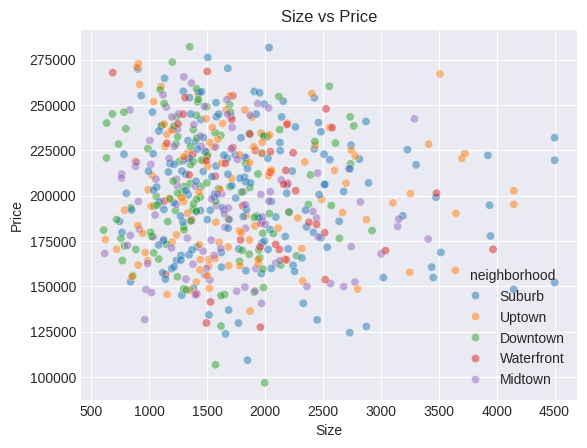

In [ ]:
sns.scatterplot(data=df, x="size", y="price", hue = "neighborhood", alpha = 0.5)
plt.title("Size vs Price")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

### Short Answer (3--4 sentences)

-   What does seaborn automatically handle that matplotlib does not?
-   Why is transparency useful here?


- Seaborn handles the statistical graphs and automatically styles the graph, including the axis and legend. Seabprn has default themes to use and it is also easier to integrate with Pandas
- Transparency is useful in this graph because there is a lot of overlapping data. Transparency allows the veiwer to see more of the data despite the overlap.

## B. Small Multiples (Faceting)

Create small multiples of **size vs price**, separated by `bedrooms`.

-   Keep scales consistent.
-   Add a clear overall title.


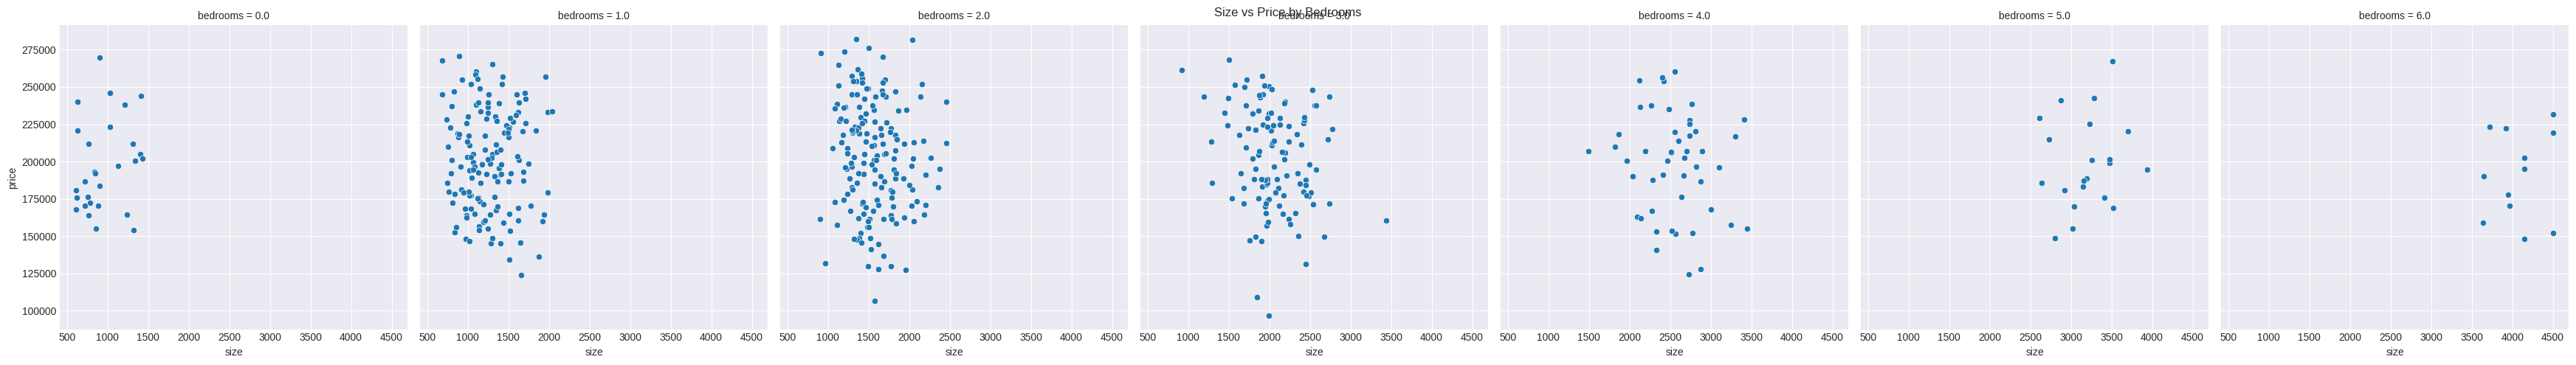

In [ ]:
sns.relplot(data=df, x="size", y="price", col="bedrooms")
plt.suptitle("Size vs Price by Bedrooms")
plt.show()

### Question

Does the relationship between size and price look similar across bedroom
counts?


Overall, the distributions look fairly similair across bedroom counts. However, the relationship between the distributions of houses with 0 bedrooms to 2 bedrooms look especially smiliar. And as the number of bedrooms increase, the distribution seems to spread out a little more.

## C. Distribution and Categorical Plots

1.  Create a histogram of `price`.
2.  Create a density plot of `price`.
3.  Create a boxplot of `price` by `neighborhood`.


### Histogram

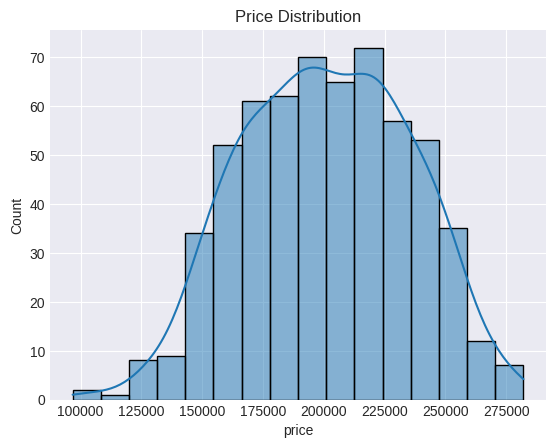

In [ ]:
sns.histplot(data=df, x="price", kde="true")
plt.title("Price Distribution")
plt.show()

### Density Plot

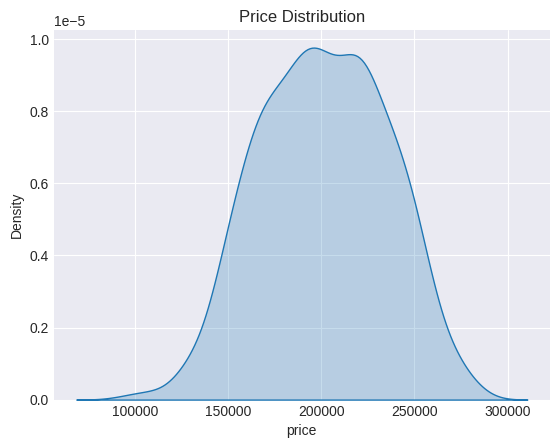

In [ ]:
sns.kdeplot(data=df, x="price", fill='true')
plt.title("Price Distribution")
plt.show()

### Box Plot

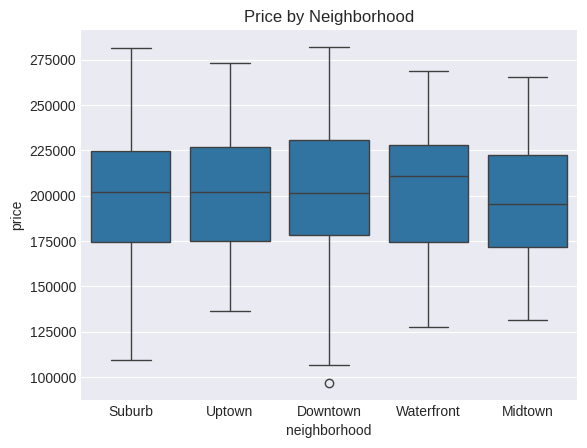

In [ ]:
sns.boxplot(data=df, x="neighborhood", y="price")
plt.title('Price by Neighborhood')
plt.show()

### Interpretation (short paragraph)

-   Do neighborhoods differ systematically in price?
-   What visual evidence supports your claim?


It does not appear that the neighborhoods differ significantly from each other in price. Each neighborhood has a similar median price and the neighboorhood with the greatest difference is the 'Waterfront' neighborhood. Even the median price of that neighborhood is within the 2nd and 3rd quartile of each of the other distributions. The biggest differnce of each neighborhood's distrubution is their spread. The Uptown, Waterfront, and Midtown neighborhood has smaller spreads, while the Suburb and Downtown neighborhoods have larger spreads.

# Part II -- Linear Regression for Inference

## A. Multiple Regression

In R, the model would be:

``` r
lm(price ~ size + bedrooms + neighborhood, data = df)
```

In Python:

1.  Fit the equivalent model using `statsmodels`.
2.  Report:
    -   Coefficient estimates
    -   Standard errors
    -   R²


In [ ]:
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


In [ ]:
model = smf.ols("price ~ size + bedrooms + neighborhood", data = df) .fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.190
Time:                        21:50:38   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
neighborhood[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
neighborhood[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
neighborhood[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
neighborhood[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                         -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                    4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## B. Interpretation

Answer clearly:

1.  Interpret the coefficient on **size**, explicitly stating what is
    being held constant.
2.  Is size statistically significant? How do you know?
3.  What does R² tell us in this context?


1. The coeffcient on **size** is -10.9345 meaning, a one unit increase in size  is associated with -10.9345 change in price, assuming bedrooms is held constant.
2. Based on the low value of P>|t| = 0.010 we can determine that the variable **size** is statistcally significant.
3. The R² value of 0.017 means that the variable **price** is barely dependent on the variables, **size**, **bedroom**, and **neighborhood**.

# Part III -- Prediction Workflow

Now switch goals: **Prediction instead of explanation**

1.  Split the data into training and test sets.
2.  Fit linear regression using `scikit-learn`.
3.  Compute:
    -   RMSE (on test set)
    -   R² (on test set)


In [ ]:
df = df.dropna()
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x = df[["size", "bedrooms"]]
y = df["price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Compute RMSE on test set
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE on test set: {rmse:.2f}")

# Compute R² on test set
r2 = r2_score(y_test, y_pred)
print(f"R-squared on test set: {r2:.2f}")

RMSE on test set: 35399.92
R-squared on test set: -0.01


## Short Answer

-   Why does scikit-learn not report p-values?
-   Which workflow would you use for:
    -   Explanation?
    -   Prediction?
-   Why are these different goals?


- Scikit-learn doesn't report p-values because p-value is a number that reports a *relationship* between variables and whether or not a variable is statistically significant, while scikit-learn is used for *perdicition*.
- Statsmodels is used for explanation, while scikit-learn is used for perdicition.
- There are different goals because both are used in statistics for different information.

# Part IV -- Integrated Thinking

Create one polished figure that:

-   Shows size vs price
-   Colors by neighborhood
-   Includes a regression line
-   Has professional formatting

Then write 4--5 sentences:

-   Does the regression model match what you visually observed?
-   Did the visualization help you anticipate the model results?

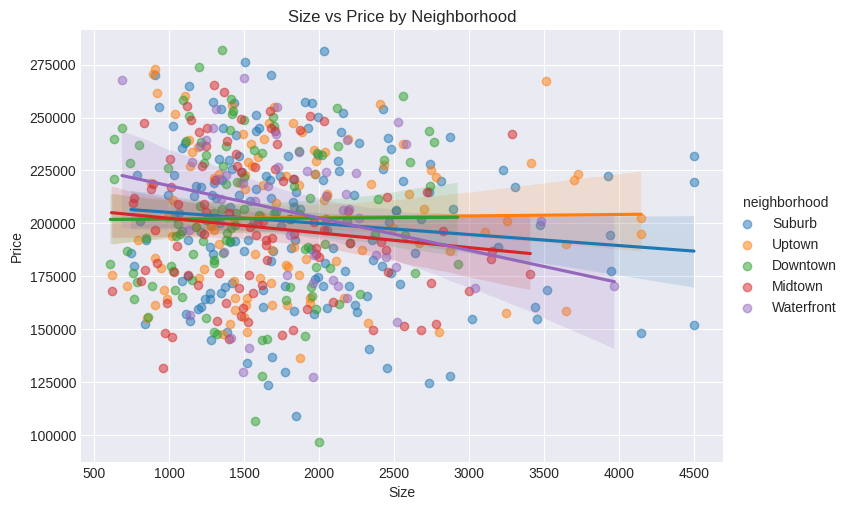

In [ ]:
sns.lmplot(data=df, x="size", y="price", hue="neighborhood", aspect=1.5, scatter_kws={'alpha':0.5})
plt.title("Size vs Price by Neighborhood")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

The model does match my analysis that the variable **size** is *not* a good indicator of the variable **price**. The visualization supports this analysis. TThe data is very messy and disorderly, which substantiates the R-squared value, indicating that there is almost no correlation between size and price. The inclusion of the variable **neighborhood** is also not hrelpful in perdicting the price and contributes to the chaos that is shown in the visualization.